# Deep Q-Learning (DQN) & Double DQN (DDQN) Tutorial

In this notebook, we implement and compare standard **Deep Q-Learning (DQN)** and **Double Deep Q-Learning (DDQN)** using PyTorch on the `CartPole-v1` Gymnasium environment.

## CartPole-v1 Environment Specification
The CartPole task is to balance a pole on a moving cart. It has a continuous state space of 4 dimensions and a discrete action space of 2 choices.

| State Component | Min | Max | Unit |
|---|---|---|---|
| Cart Position | -4.8 | 4.8 | meters |
| Cart Velocity | -Inf | Inf | m/s |
| Pole Angle | ~ -24° | ~ 24° | radians |
| Pole Angular Velocity | -Inf | Inf | rad/s |

| Action | Description |
|---|---|
| `0` | Push cart to the left |
| `1` | Push cart to the right |

---

## 1. Replay Buffer

Deep neural networks are prone to **catastrophic forgetting** and instability when trained on highly correlated, sequential data. The **Replay Buffer** solves this by storing agent transitions and sampling random batches to break temporal correlations.

<svg width="700" height="180" viewBox="0 0 700 180" xmlns="http://www.w3.org/2000/svg">
  <rect width="700" height="180" fill="#f8f9fa" rx="8" ry="8" stroke="#dee2e6"/>
  <text x="350" y="25" font-family="Arial" font-size="14" font-weight="bold" fill="#333" text-anchor="middle">Replay Buffer Data Flow</text>
  
  <!-- Agent / Transition Input -->
  <rect x="30" y="60" width="130" height="50" fill="#e3f2fd" stroke="#2196f3" stroke-width="1.5" rx="5" ry="5"/>
  <text x="95" y="82" font-family="Arial" font-size="11" font-weight="bold" fill="#0d47a1" text-anchor="middle">Transition Input</text>
  <text x="95" y="98" font-family="Arial" font-size="10" fill="#0d47a1" text-anchor="middle">(s, a, r, s', done)</text>
  
  <line x1="160" y1="85" x2="220" y2="85" stroke="#333" stroke-width="2" marker-end="url(#arrow-head)"/>
  
  <!-- Buffer Storage -->
  <rect x="220" y="50" width="260" height="75" fill="#fff9c4" stroke="#fbc02d" stroke-width="1.5" rx="5" ry="5"/>
  <text x="350" y="70" font-family="Arial" font-size="12" font-weight="bold" fill="#f57f17" text-anchor="middle">FIFO Circular Queue</text>
  <rect x="235" y="82" width="70" height="30" fill="#fffde7" stroke="#fbc02d" rx="3" ry="3"/>
  <text x="270" y="100" font-family="Arial" font-size="10" fill="#f57f17" text-anchor="middle">Batch 1</text>
  <rect x="315" y="82" width="70" height="30" fill="#fffde7" stroke="#fbc02d" rx="3" ry="3"/>
  <text x="350" y="100" font-family="Arial" font-size="10" fill="#f57f17" text-anchor="middle">Batch 2</text>
  <rect x="395" y="82" width="70" height="30" fill="#fffde7" stroke="#fbc02d" rx="3" ry="3"/>
  <text x="430" y="100" font-family="Arial" font-size="10" fill="#f57f17" text-anchor="middle">Batch 3</text>
  
  <line x1="480" y1="85" x2="540" y2="85" stroke="#333" stroke-width="2" marker-head="url(#arrow-head)"/>
  
  <!-- Random Batch Output -->
  <rect x="540" y="60" width="130" height="50" fill="#e8f5e9" stroke="#4caf50" stroke-width="1.5" rx="5" ry="5"/>
  <text x="605" y="82" font-family="Arial" font-size="11" font-weight="bold" fill="#1b5e20" text-anchor="middle">Random Sample</text>
  <text x="605" y="98" font-family="Arial" font-size="10" fill="#1b5e20" text-anchor="middle">Minibatch Update</text>
  
  <defs>
    <marker id="arrow-head" markerWidth="6" markerHeight="6" refX="2" refY="3" orient="auto">
      <path d="M0,0 L0,6 L6,3 z" fill="#333"/>
    </marker>
  </defs>
</svg>

In [1]:
import random
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        return (np.array(state, dtype=np.float32),
                np.array(action, dtype=np.int64),
                np.array(reward, dtype=np.float32),
                np.array(next_state, dtype=np.float32),
                np.array(done, dtype=np.float32))
        
    def __len__(self):
        return len(self.buffer)

## 2. Q-Network

We parameterize our action-value function $Q(s, a; \theta)$ with a 3-layer fully-connected neural network. 
- **Input layer:** Dimension matches the state space (4 for CartPole).
- **Hidden layers:** Two layers of 64 units with ReLU activations.
- **Output layer:** Dimension matches action choices (2 for CartPole), outputting unscaled action values.

In [2]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.net(x)

## 3. DQN vs. Double DQN target value calculations

Standard DQN suffers from **overestimation bias** because of the $\max$ operator in the target calculation:
$$ Y_t^{\text{DQN}} = R_{t+1} + \gamma \max_a Q(S_{t+1}, a; \theta^-) $$

Double DQN resolves this by decoupling **action selection** (done by the online network $\theta$) from **action evaluation** (done by the target network $\theta^-$):
$$ Y_t^{\text{DDQN}} = R_{t+1} + \gamma Q\left(S_{t+1}, \text{argmax}_a Q(S_{t+1}, a; \theta); \theta^-\right) $$

<svg width="700" height="160" viewBox="0 0 700 160" xmlns="http://www.w3.org/2000/svg">
  <rect width="700" height="160" fill="#f8f9fa" rx="8" ry="8" stroke="#dee2e6"/>
  <text x="350" y="20" font-family="Arial" font-size="13" font-weight="bold" fill="#333" text-anchor="middle">Target Calculations Comparison</text>
  
  <!-- Standard DQN Path -->
  <g transform="translate(50, 40)">
    <rect width="280" height="100" fill="#ffebee" stroke="#ef5350" stroke-width="1.5" rx="5" ry="5"/>
    <text x="140" y="22" font-family="Arial" font-size="11" font-weight="bold" fill="#c62828" text-anchor="middle">Standard DQN Target</text>
    <text x="140" y="50" font-family="Courier New" font-size="12" font-weight="bold" fill="#333" text-anchor="middle">Y = R + γ · Max Q(S', a; θ⁻)</text>
    <text x="140" y="80" font-family="Arial" font-size="9" fill="#555" text-anchor="middle">Target network (θ⁻) selects &amp; evaluates the action</text>
  </g>
  
  <!-- Double DQN Path -->
  <g transform="translate(370, 40)">
    <rect width="280" height="100" fill="#e8f5e9" stroke="#66bb6a" stroke-width="1.5" rx="5" ry="5"/>
    <text x="140" y="22" font-family="Arial" font-size="11" font-weight="bold" fill="#2e7d32" text-anchor="middle">Double DQN Target</text>
    <text x="140" y="50" font-family="Courier New" font-size="12" font-weight="bold" fill="#333" text-anchor="middle">Y = R + γ · Q(S', argmax Q(S',a; θ); θ⁻)</text>
    <text x="140" y="80" font-family="Arial" font-size="9" fill="#555" text-anchor="middle">Online network (θ) selects. Target network (θ⁻) evaluates.</text>
  </g>
</svg>

In [3]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, double_dqn=False, device="cpu"):
        self.action_dim = action_dim
        self.double_dqn = double_dqn
        self.device = device
        
        # Initialize Q networks
        self.q_online = QNetwork(state_dim, action_dim).to(device)
        self.q_target = QNetwork(state_dim, action_dim).to(device)
        self.sync_target()
        
        self.optimizer = optim.Adam(self.q_online.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        
    def sync_target(self):
        self.q_target.load_state_dict(self.q_online.state_dict())
        
    def act(self, state, epsilon):
        if random.random() < epsilon:
            return random.randint(0, self.action_dim - 1)
        
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_online(state_t)
        return q_values.argmax(dim=1).item()
        
    def update(self, batch, gamma):
        states, actions, rewards, next_states, dones = batch
        
        states_t = torch.FloatTensor(states).to(self.device)
        actions_t = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards_t = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states_t = torch.FloatTensor(next_states).to(self.device)
        dones_t = torch.FloatTensor(dones).unsqueeze(1).to(self.device)
        
        # Current Q-values predicted by online network
        q_values = self.q_online(states_t).gather(1, actions_t)
        
        # Compute targets
        with torch.no_grad():
            if self.double_dqn:
                # 1. Action selection using online network
                next_actions = self.q_online(next_states_t).argmax(dim=1, keepdim=True)
                # 2. Action evaluation using target network
                next_q_values = self.q_target(next_states_t).gather(1, next_actions)
            else:
                # Standard DQN
                next_q_values = self.q_target(next_states_t).max(dim=1, keepdim=True)[0]
                
            targets = rewards_t + (1 - dones_t) * gamma * next_q_values
            
        loss = self.loss_fn(q_values, targets)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()

## 4. The Training Loop

The training loop coordinates environment rollouts, populates the replay buffer, samples updates for the agent, and manages linear/exponential decay of $\epsilon$-greedy exploration.

In [4]:
def train_agent(env, agent, capacity=10000, batch_size=64, num_episodes=150, 
                gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.98, 
                target_sync_freq=10):
    
    buffer = ReplayBuffer(capacity)
    episode_rewards = []
    epsilon = epsilon_start
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            action = agent.act(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            
            # Update model if buffer has enough items
            if len(buffer) >= batch_size:
                batch = buffer.sample(batch_size)
                agent.update(batch, gamma)
                
        episode_rewards.append(total_reward)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        
        # Sync target network
        if episode % target_sync_freq == 0:
            agent.sync_target()
            
        if (episode + 1) % 25 == 0:
            avg_reward = np.mean(episode_rewards[-25:])
            print(f"Episode {episode+1:03d} | Epsilon: {epsilon:.3f} | 25-Episode Avg Reward: {avg_reward:.1f}")
            
    return episode_rewards

## 5. Experiment & Comparison

We run standard DQN and Double DQN side-by-side on the same environment. To ensure stable rewards, CartPole-v1 rewards the agent with +1 for each timestep the pole remains upright. The maximum duration is 500 steps.

In [5]:
import gymnasium as gym
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training using device: {device}")

env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# 1. Train Standard DQN
print("\n--- Training Standard DQN Agent ---")
dqn_agent = DQNAgent(state_dim, action_dim, lr=1e-3, double_dqn=False, device=device)
dqn_rewards = train_agent(env, dqn_agent, num_episodes=150)

# 2. Train Double DQN
print("\n--- Training Double DQN Agent ---")
ddqn_agent = DQNAgent(state_dim, action_dim, lr=1e-3, double_dqn=True, device=device)
ddqn_rewards = train_agent(env, ddqn_agent, num_episodes=150)

env.close()

Training using device: cpu

--- Training Standard DQN Agent ---
Episode 025 | Epsilon: 0.603 | 25-Episode Avg Reward: 19.5
Episode 050 | Epsilon: 0.364 | 25-Episode Avg Reward: 46.2
Episode 075 | Epsilon: 0.220 | 25-Episode Avg Reward: 186.8
Episode 100 | Epsilon: 0.133 | 25-Episode Avg Reward: 252.7
Episode 125 | Epsilon: 0.080 | 25-Episode Avg Reward: 197.8
Episode 150 | Epsilon: 0.048 | 25-Episode Avg Reward: 146.1

--- Training Double DQN Agent ---
Episode 025 | Epsilon: 0.603 | 25-Episode Avg Reward: 20.6
Episode 050 | Epsilon: 0.364 | 25-Episode Avg Reward: 27.6
Episode 075 | Epsilon: 0.220 | 25-Episode Avg Reward: 140.2
Episode 100 | Epsilon: 0.133 | 25-Episode Avg Reward: 234.4
Episode 125 | Epsilon: 0.080 | 25-Episode Avg Reward: 285.5
Episode 150 | Epsilon: 0.048 | 25-Episode Avg Reward: 283.9


## 6. Plotting Results

We calculate the rolling 10-episode mean to smooth out random exploration noise and compare convergence speeds.

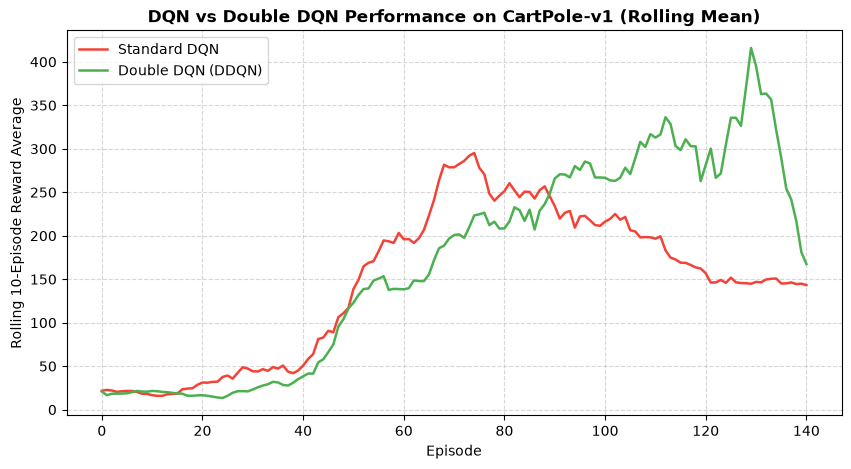

In [6]:
def rolling_mean(arr, window=10):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(rolling_mean(dqn_rewards), label="Standard DQN", color="#f44336", linewidth=1.8)
plt.plot(rolling_mean(ddqn_rewards), label="Double DQN (DDQN)", color="#4caf50", linewidth=1.8)
plt.title("DQN vs Double DQN Performance on CartPole-v1 (Rolling Mean)", fontsize=12, fontweight='bold')
plt.xlabel("Episode", fontsize=10)
plt.ylabel("Rolling 10-Episode Reward Average", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)
plt.show()